
El glioblastoma (GBM) es el tumor cerebral primario más agresivo y se caracteriza por una elevada heterogeneidad celular, lo que dificulta tanto su comprensión biológica como el desarrollo de tratamientos efectivos. En este contexto, los datos de secuenciación de ARN a nivel de célula única (*single-cell RNA sequencing*, scRNA-seq) permiten analizar la expresión génica célula a célula, proporcionando una resolución adecuada para estudiar la complejidad tumoral.

En este experimento se emplea un dataset público de glioblastoma obtenido del portal del **Broad Institute (Single Cell Portal)**, disponible en el siguiente enlace:  
https://singlecell.broadinstitute.org/single_cell/study/SCP393/single-cell-rna-seq-of-adult-and-pediatric-glioblastoma#study-download

En particular, este experimento se centra en el subconjunto 10X del dataset, el cual no dispone de anotaciones celulares compatibles para un escenario supervisado convencional. Por ello, se plantea una aproximación basada en pseudoetiquetas obtenidas mediante clustering no supervisado.



# **Configuración**

## **Configuración de dependencias y librerías**


In [ ]:
# Instalación librerías
%pip install -q --upgrade pip setuptools wheel
!pip install -q "numpy==1.26.4" "scipy==1.12.0" "pandas==2.2.2" "matplotlib==3.8.4" "seaborn==0.13.2"
!pip install -q "h5py==3.11.0" "anndata==0.10.8" "scanpy==1.10.1" "scikit-learn==1.5.1"
!pip install -q "jedi>=0.19.1"
%pip install -q "statsmodels>=0.14" "h5py==3.11.0" "KDEpy==1.1.9"
!pip install -q igraph leidenalg

# Deep learning
%pip install -q torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cpu
%pip install -q dgl==1.1.3 -f https://data.dgl.ai/wheels/repo.html


!pip uninstall -y numpy
!pip install -q "numpy==1.26.4"
!pip install -q igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.12.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are in

Reiniciar entorno

In [ ]:
import numpy as np
import scipy
import pandas as pd
import scanpy as sc
import anndata as ad
import sklearn
import h5py
from scipy import sparse

print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("pandas:", pd.__version__)
print("scanpy:", sc.__version__)
print("anndata:", ad.__version__)
print("sklearn:", sklearn.__version__)
print("h5py:", h5py.__version__)

numpy: 1.26.4
scipy: 1.12.0
pandas: 2.2.2
scanpy: 1.10.1
anndata: 0.10.8
sklearn: 1.5.1
h5py: 3.11.0


# **1. Carga e inspección inicial de los datos**






## **1.1. Archivos utilizados en este experimento**

El conjunto de datos empleado en este experimento procede del repositorio **Single Cell Portal** del **Broad Institute**, concretamente del estudio **SCP393**, correspondiente a datos de secuenciación de ARN de célula única en glioblastoma adulto y pediátrico. Los archivos utilizados para la reconstrucción del objeto de análisis son los siguientes:

- **Matriz de expresión génica**  
  `IDHwtGBM.processed.10X.counts.mtx`  
  Contiene los niveles de expresión génica en formato disperso, generados mediante tecnología 10X Genomics.

- **Archivo de genes**  
  `genes1.tsv`  
  Incluye los identificadores de los genes correspondientes a las columnas de la matriz.

- **Archivo de células**  
  `cells1.proc.tsv`  
  Contiene los identificadores únicos de las células (barcodes), que corresponden a las filas de la matriz.

- **Archivo de metadatos**  
  `IDHwt.GBM.Metadata.SS2.txt`  
  Proporciona información adicional sobre células procedentes de un experimento de secuenciación distinto (Smart-seq2), incluyendo anotaciones biológicas y métricas derivadas.


### **1.1.1. Montar Google Drive (Verificación y Reintento)**



In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
from google.colab import drive

# Verificar si Drive ya está montado
if not os.path.exists('/content/drive'):
    print("Google Drive no está montado. Intentando montarlo...")
    try:
        drive.mount('/content/drive', force_remount=True)
        print("Google Drive montado exitosamente.")
    except Exception as e:
        print(f"Error al montar Google Drive: {e}")
else:
    print("Google Drive ya está montado.")

Google Drive ya está montado.


### **1.1.2. Listar archivos en un directorio de Drive**


In [ ]:
import os

# Define la ruta a tu directorio en Google Drive
# Sustituye 'MyDrive/Colab Notebooks/Experimento2_gliobastoma/data' con la ruta correcta si es diferente
drive_directory_path = "/content/drive/MyDrive/Colab Notebooks/Experimento2_gliobastoma/data"

# Verifica si el directorio existe antes de intentar listar su contenido
if os.path.exists(drive_directory_path):
    print(f"Archivos en '{drive_directory_path}':")
    for item in os.listdir(drive_directory_path):
        print(item)
else:
    print(f"El directorio '{drive_directory_path}' no existe o no se pudo acceder.")

Archivos en '/content/drive/MyDrive/Colab Notebooks/Experimento2_gliobastoma/data':
genes1.tsv
cells1.proc.tsv
IDHwtGBM.processed.10X.counts.mtx
IDHwt.GBM.Metadata.SS2.txt


In [ ]:
import os
data_dir = "/content/drive/MyDrive/Colab Notebooks/Experimento2_gliobastoma/data"
print(os.listdir(data_dir))

['genes1.tsv', 'cells1.proc.tsv', 'IDHwtGBM.processed.10X.counts.mtx', 'IDHwt.GBM.Metadata.SS2.txt']


### **Si no funciona montar drive:** cargar de forma manual los datos

In [ ]:
#!unzip data.zip

## **1.2. Carga y estructuración de los datos**



### **1.2.1. Carga del objeto AnnData**

El objeto `AnnData` constituye la estructura central para el análisis de datos scRNA-seq en el ecosistema `scverse`.

Para su construcción se utilizan los siguientes archivos:

- `IDHwtGBM.processed.10X.counts.mtx`: matriz de expresión génica en formato disperso,
- `genes1.tsv`: identificadores de genes,
- `cells1.proc.tsv`: identificadores celulares.



In [ ]:
import scanpy as sc
import pandas as pd
import os

# SI NO FUNCIONA MONTAR DIRVE: Ahora la ruta es la carpeta local descomprimida
#data_dir = "data"
# ---------------------------------------------------------------------------

mtx_path = os.path.join(data_dir, "IDHwtGBM.processed.10X.counts.mtx")
genes_path = os.path.join(data_dir, "genes1.tsv")
cells_path = os.path.join(data_dir, "cells1.proc.tsv")
metadata_path = os.path.join(data_dir, "IDHwt.GBM.Metadata.SS2.txt")

# Carga matriz
adata = sc.read_mtx(mtx_path).T

# Carga genes y células
genes = pd.read_csv(genes_path, header=None, sep="\t")
cells = pd.read_csv(cells_path, header=None, sep="\t")

adata.var_names = genes[0].astype(str).values
adata.obs_names = cells[0].astype(str).values

print(adata)
print("Primeras células:", adata.obs_names[:10].tolist())
print("Primeros genes:", adata.var_names[:10].tolist())

AnnData object with n_obs × n_vars = 12074 × 32738
Primeras células: ['102_1', '102_2', '102_4', '102_5', '102_7', '102_8', '102_10', '102_11', '102_12', '102_13']
Primeros genes: ['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092', 'ENSG00000238009', 'ENSG00000239945', 'ENSG00000237683', 'ENSG00000239906', 'ENSG00000241599', 'ENSG00000228463', 'ENSG00000237094']


### **1.2.2. Carga de los metadatos**

De forma independiente, se cargan los metadatos disponibles en el archivo:

- `IDHwt.GBM.Metadata.SS2.txt`

Este fichero contiene información adicional sobre las células, incluyendo:

- anotaciones biológicas (por ejemplo, tipo celular o estado tumoral),
- variables cuantitativas derivadas de la expresión génica,
- y características experimentales.

La carga de estos datos permite analizar su estructura y evaluar su posible integración con el objeto `AnnData`.

In [ ]:
# Carga metadata
metadata = pd.read_csv(metadata_path, sep="\t", index_col=0)

print("Dimensiones metadata:", metadata.shape)
print("Columnas metadata:")
print(metadata.columns.tolist())

print("\nPrimeros índices del metadata:")
print(metadata.index[:10].tolist())

Dimensiones metadata: (7931, 14)
Columnas metadata:
['Sample', 'GBMType', 'CellAssignment', 'CrossSection', 'GenesExpressed', 'GeneticSubclone', 'MESlike2', 'MESlike1', 'AClike', 'OPClike', 'NPClike1', 'NPClike2', 'G1S', 'G2M']

Primeros índices del metadata:
['TYPE', 'MGH100-P5-A01', 'MGH100-P5-A03', 'MGH100-P5-A04', 'MGH100-P5-A06', 'MGH100-P5-A07', 'MGH100-P5-A08', 'MGH100-P5-A09', 'MGH100-P5-A10', 'MGH100-P5-A12']


## **1.3. Inspección de los datos**
Una vez cargados los distintos componentes del dataset, se realiza una fase de inspección.

In [ ]:
print("Primeras obs_names de adata:")
print(adata.obs_names[:10].tolist())

print("\nPrimeros índices del metadata:")
print(metadata.index[:10].tolist())

Primeras obs_names de adata:
['102_1', '102_2', '102_4', '102_5', '102_7', '102_8', '102_10', '102_11', '102_12', '102_13']

Primeros índices del metadata:
['TYPE', 'MGH100-P5-A01', 'MGH100-P5-A03', 'MGH100-P5-A04', 'MGH100-P5-A06', 'MGH100-P5-A07', 'MGH100-P5-A08', 'MGH100-P5-A09', 'MGH100-P5-A10', 'MGH100-P5-A12']


In [ ]:
metadata_raw = pd.read_csv(metadata_path, sep="\t", header=None)
print(metadata_raw.head(10))
print(metadata_raw.shape)

              0       1        2               3             4   \
0           NAME  Sample  GBMType  CellAssignment  CrossSection   
1           TYPE   group    group           group         group   
2  MGH100-P5-A01  MGH100    Adult       Malignant          none   
3  MGH100-P5-A03  MGH100    Adult       Malignant          none   
4  MGH100-P5-A04  MGH100    Adult       Malignant          none   
5  MGH100-P5-A06  MGH100    Adult       Malignant          none   
6  MGH100-P5-A07  MGH100    Adult       Malignant          none   
7  MGH100-P5-A08  MGH100    Adult       Malignant          none   
8  MGH100-P5-A09  MGH100    Adult       Malignant          none   
9  MGH100-P5-A10  MGH100    Adult       Malignant          none   

               5                6                   7                    8   \
0  GenesExpressed  GeneticSubclone            MESlike2             MESlike1   
1         numeric            group             numeric              numeric   
2            7403        

Durante la carga e inspección, se observa que los identificadores de la matriz (102_1, 102_2, etc.) no coinciden con los identificadores del fichero de metadatos (MGH100-P5-A01, MGH100-P5-A03, etc.).

Esto indica que los metadatos cargados no corresponden al mismo subconjunto tecnológico que la matriz de expresión utilizada. En concreto, la matriz principal procede de datos procesados en formato 10X, mientras que el fichero de metadatos disponible corresponde a células SS2.

Como consecuencia, el siguiente bloque del análisis se centrará en el preprocesado técnico y la exploración no supervisada de la matriz 10X.

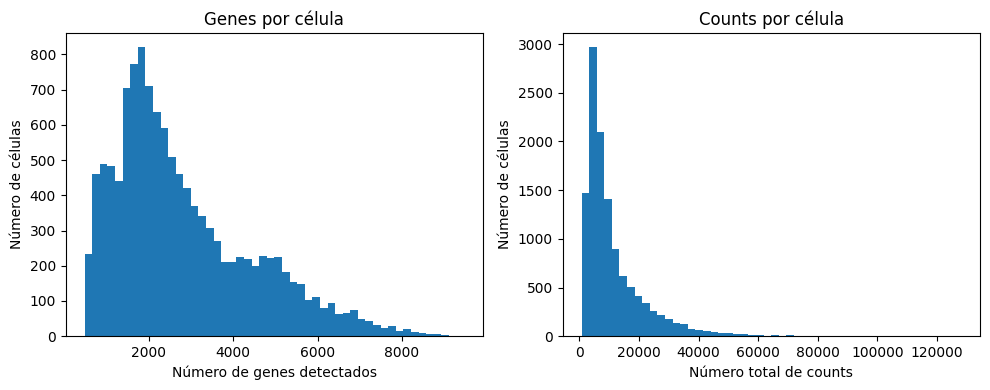

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Métricas
n_genes = (adata.X > 0).sum(axis=1)
n_genes = np.array(n_genes).flatten()

n_counts = adata.X.sum(axis=1)
n_counts = np.array(n_counts).flatten()

# Figura conjunta
plt.figure(figsize=(10,4))

# --- Histograma genes ---
plt.subplot(1,2,1)
plt.hist(n_genes, bins=50)
plt.xlabel("Número de genes detectados")
plt.ylabel("Número de células")
plt.title("Genes por célula")

# --- Histograma counts ---
plt.subplot(1,2,2)
plt.hist(n_counts, bins=50)
plt.xlabel("Número total de counts")
plt.ylabel("Número de células")
plt.title("Counts por célula")

plt.tight_layout()
plt.show()

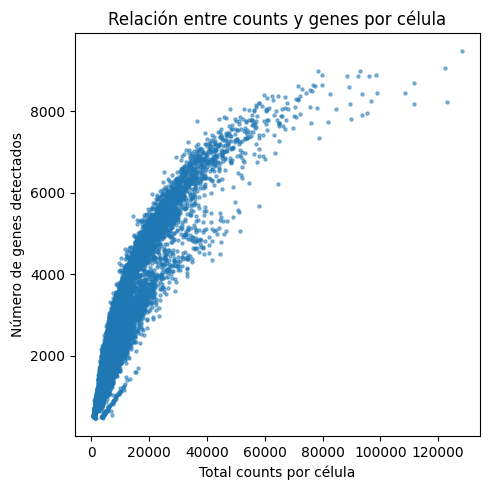

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(n_counts, n_genes, s=5, alpha=0.5)
plt.xlabel("Total counts por célula")
plt.ylabel("Número de genes detectados")
plt.title("Relación entre counts y genes por célula")
plt.tight_layout()
plt.show()

In [ ]:
import scipy.sparse as sp

if sp.issparse(adata.X):
    sparsity = 1.0 - (adata.X.nnz / (adata.X.shape[0] * adata.X.shape[1]))
else:
    sparsity = 1.0 - (np.count_nonzero(adata.X) / adata.X.size)

print(f"Sparsity: {sparsity:.4f}")

Sparsity: 0.9140


# **2. Preprocesamiento y visualización**


## **2.1. Inspección inicial del objeto AnnData**

Una vez cargado el conjunto de datos en secciones previas, se realiza una inspección inicial del objeto `AnnData` con el objetivo de verificar su estructura interna y detectar posibles inconsistencias antes de iniciar el preprocesado.

El objeto presenta la siguiente estructura:


In [ ]:
print(adata)


AnnData object with n_obs × n_vars = 12074 × 32738



Esto indica que el dataset contiene **12.074 observaciones (barcodes celulares)** y **32.738 variables (genes)**. En este contexto, cada fila de la matriz representa un *barcode* celular y cada columna un gen, correspondiéndose con una matriz de conteos génicos típica de datos 10X.

A continuación, se realiza una comprobación básica de los identificadores de células y genes, así como de la estructura interna del objeto.

Es importante destacar que, en muchos datasets de scRNA-seq, los identificadores génicos pueden no ser únicos. La presencia de nombres duplicados puede provocar errores o comportamientos inesperados en etapas posteriores del análisis, como la selección de genes altamente variables o la reducción de dimensionalidad.

Por este motivo, se verifica la unicidad de los nombres de genes y, en caso necesario, se corrigen mediante la función `var_names_make_unique()`, que garantiza identificadores únicos añadiendo sufijos numéricos a los duplicados.

Asimismo, se inspecciona la información adicional almacenada en `adata.var`, que en este caso contiene identificadores génicos en formato Ensembl.

Finalmente, es importante tener en cuenta que no todas las observaciones del dataset representan necesariamente células individuales válidas. Entre los posibles artefactos presentes en datos de célula única se incluyen:

- células de baja calidad,
- ARN libre ambiental (*ambient RNA*),
- dobles capturas celulares (*doublets*).

Estas desviaciones serán abordadas en las siguientes etapas del preprocesado.




### **2.2.1. Verificación del objeto y estructura básica**

In [ ]:
print(adata)
print("Dimensiones:", adata.shape)
print(cells.shape)
print(genes.shape)

print("\nPrimeras células:")
print(adata.obs_names[:10].tolist())

print("\nPrimeros genes:")
print(adata.var_names[:10].tolist())
print(adata.var_names[:10])

AnnData object with n_obs × n_vars = 12074 × 32738
Dimensiones: (12074, 32738)
(12074, 1)
(32738, 2)

Primeras células:
['102_1', '102_2', '102_4', '102_5', '102_7', '102_8', '102_10', '102_11', '102_12', '102_13']

Primeros genes:
['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092', 'ENSG00000238009', 'ENSG00000239945', 'ENSG00000237683', 'ENSG00000239906', 'ENSG00000241599', 'ENSG00000228463', 'ENSG00000237094']
Index(['ENSG00000243485', 'ENSG00000237613', 'ENSG00000186092',
       'ENSG00000238009', 'ENSG00000239945', 'ENSG00000237683',
       'ENSG00000239906', 'ENSG00000241599', 'ENSG00000228463',
       'ENSG00000237094'],
      dtype='object')


### **2.2.2. Validación de nombres de genes**

In [ ]:
# Comprobación de duplicados en nombres de genes
duplicados = adata.var_names.duplicated().sum()
print("Número de genes duplicados:", duplicados)

# Corrección si es necesario
adata.var_names_make_unique()

print("Corrección aplicada. Nombres únicos garantizados.")

Número de genes duplicados: 0
Corrección aplicada. Nombres únicos garantizados.


Tras la corrección, se garantiza que cada gen posee un identificador único, lo que permite evitar inconsistencias en las etapas posteriores del análisis.



### **2.2.3. Inspección de nombres de genes**

In [ ]:
print("Columnas en adata.var:")
print(adata.var.columns.tolist())

print("\nPrimeras filas de adata.var:")
print(adata.var.head())


Columnas en adata.var:
[]

Primeras filas de adata.var:
Empty DataFrame
Columns: []
Index: [ENSG00000243485, ENSG00000237613, ENSG00000186092, ENSG00000238009, ENSG00000239945]


Esto implica que no se dispone de información adicional sobre los genes, como nombres simbólicos (gene symbols), tipos de característica (feature types) o anotaciones genómicas.

En particular, los genes están identificados mediante **códigos Ensembl**, lo que limita la interpretación biológica directa de los resultados. Por ejemplo, no es posible identificar de forma inmediata genes mitocondriales, ribosomales o marcadores celulares conocidos basándose únicamente en prefijos habituales (como MT- o RPL).


### **2.2.4. Copia del objeto para preprocesado**

Antes de iniciar el pipeline de preprocesado, se genera una copia del objeto original. Esta práctica permite conservar una versión intacta de los datos cargados, facilitando la reproducibilidad del análisis y la posibilidad de volver atrás en caso necesario.

In [ ]:
adata_pp = adata.copy()

print("Copia creada correctamente")
print(adata_pp)

Copia creada correctamente
AnnData object with n_obs × n_vars = 12074 × 32738


## **2.2. Control de calidad (Quality Control)**

In [ ]:
# Copia de trabajo para preprocesado y control de calidad
adata_qc = adata.copy()

print("Objeto de trabajo para QC:")
print(adata_qc)

Objeto de trabajo para QC:
AnnData object with n_obs × n_vars = 12074 × 32738


### **2.2.1. Cálculo de métricas de control de calidad**

Una vez definido el objeto de trabajo, se calculan métricas generales de control de calidad sobre las observaciones y variables del dataset.

La función `calculate_qc_metrics()` de **Scanpy** permite obtener de forma automatizada diversas métricas ampliamente utilizadas en datos de transcriptómica de célula única.


In [ ]:
# Cálculo de métricas generales de QC
sc.pp.calculate_qc_metrics(adata_qc, inplace=True, log1p=True)

print("Columnas de QC añadidas a adata_qc.obs:")
print(adata_qc.obs.columns.tolist())

Columnas de QC añadidas a adata_qc.obs:
['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes']


### **2.2.2. Visualización de métricas de control de calidad**

Una vez calculadas las métricas de calidad, se inspeccionan visualmente algunas de las más relevantes, en particular:

- el número de genes detectados por observación (`n_genes_by_counts`),
- el número total de conteos por observación (`total_counts`).


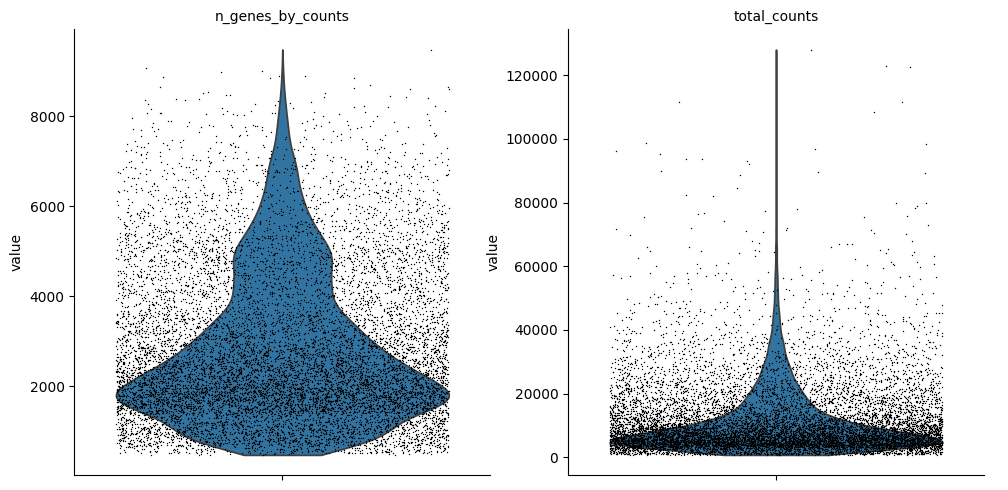

In [ ]:
# Visualización de métricas básicas de QC
sc.pl.violin(
    adata_qc,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True
)

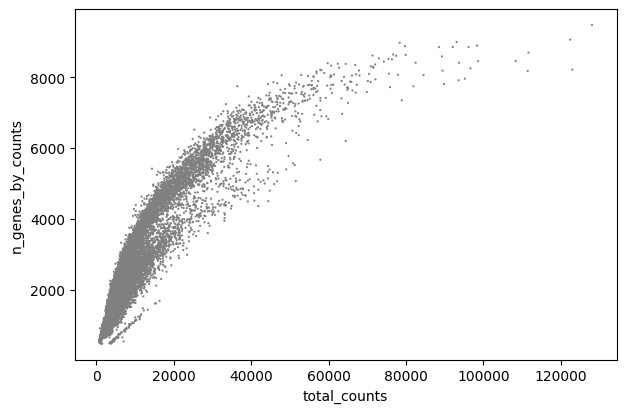

In [ ]:
# Relación entre número total de conteos y número de genes detectados
sc.pl.scatter(
    adata_qc,
    x="total_counts",
    y="n_genes_by_counts"
)

### **2.2.3. Filtrado básico de células y genes**

A partir de las métricas de calidad calculadas, se aplica un filtrado inicial de carácter permisivo, con el objetivo de eliminar únicamente observaciones y variables claramente poco informativas sin comprometer la posible presencia de subpoblaciones celulares raras.

Se eliminan:

- las observaciones con menos de 100 genes detectados,
- y los genes detectados en menos de 3 observaciones.



In [ ]:
print("Dimensiones antes del filtrado básico:", adata_qc.shape)

# Filtrado básico y permisivo
sc.pp.filter_cells(adata_qc, min_genes=100)
sc.pp.filter_genes(adata_qc, min_cells=3)

print("Dimensiones después del filtrado básico:", adata_qc.shape)

Dimensiones antes del filtrado básico: (12074, 32738)
Dimensiones después del filtrado básico: (12074, 23386)


In [ ]:
# Umbral inspirado en Neftel et al. para datos 10X:
# conservar células con número de genes detectados entre 0.5x y 2x la media global

mean_genes = adata_qc.obs["n_genes_by_counts"].mean()

lower_thr = 0.5 * mean_genes
upper_thr = 2.0 * mean_genes

print(f"Media de genes detectados por célula: {mean_genes:.2f}")
print(f"Umbral inferior: {lower_thr:.2f}")
print(f"Umbral superior: {upper_thr:.2f}")

adata_qc.obs["qc_paper_filter"] = (
    (adata_qc.obs["n_genes_by_counts"] >= lower_thr) &
    (adata_qc.obs["n_genes_by_counts"] <= upper_thr)
)

print("Células antes del filtro:", adata_qc.n_obs)
print(adata_qc.obs["qc_paper_filter"].value_counts())

adata_qc = adata_qc[adata_qc.obs["qc_paper_filter"]].copy()

print("Células después del filtro:", adata_qc.n_obs)

Media de genes detectados por célula: 2815.68
Umbral inferior: 1407.84
Umbral superior: 5631.36
Células antes del filtro: 12074
qc_paper_filter
True     8978
False    3096
Name: count, dtype: int64
Células después del filtro: 8978


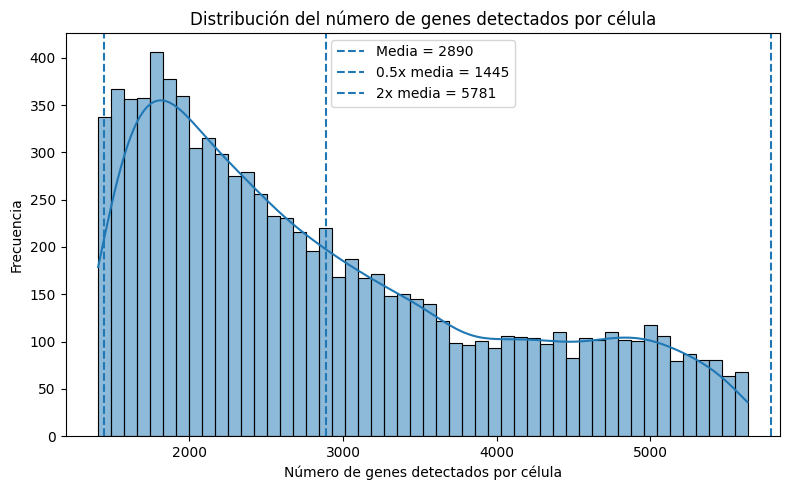

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

n_genes = adata_qc.obs["n_genes_by_counts"]

mean_genes = n_genes.mean()
lower_thr = 0.5 * mean_genes
upper_thr = 2.0 * mean_genes

plt.figure(figsize=(8,5))

# Histograma suavizado
sns.histplot(n_genes, bins=50, kde=True)

# Líneas tipo Neftel
plt.axvline(mean_genes, linestyle='--', label=f"Media = {mean_genes:.0f}")
plt.axvline(lower_thr, linestyle='--', label=f"0.5x media = {lower_thr:.0f}")
plt.axvline(upper_thr, linestyle='--', label=f"2x media = {upper_thr:.0f}")

plt.xlabel("Número de genes detectados por célula")
plt.ylabel("Frecuencia")
plt.title("Distribución del número de genes detectados por célula")

plt.legend()
plt.tight_layout()
plt.show()

### **2.2.4. Filtrado adicional de genes de baja detección**

Tras el filtrado básico, se aplica un criterio adicional sobre las variables con el fin de reducir ruido técnico y eliminar genes escasamente representados. Para ello, se conservan únicamente aquellos genes detectados en al menos 20 células.



In [ ]:
print(f"Número total de genes antes del filtrado adicional: {adata_qc.n_vars}")

sc.pp.filter_genes(adata_qc, min_cells=20)

print(f"Número de genes tras el filtrado adicional: {adata_qc.n_vars}")

Número total de genes antes del filtrado adicional: 23386
Número de genes tras el filtrado adicional: 18387


### **2.2.5. Detección de dobles**

Para esta tarea se emplea el método **Scrublet**, disponible directamente en **Scanpy**. Este algoritmo estima la probabilidad de que una observación sea un doblete comparando los transcriptomas observados con dobles simulados generados artificialmente.

Como resultado, Scanpy incorpora al objeto `AnnData` dos nuevas columnas en `adata.obs`:

- `doublet_score`, que representa la puntuación de doblete asignada a cada observación.
- `predicted_doublet`, que indica si la observación ha sido clasificada como posible doblete.

En este trabajo, se calcula inicialmente la puntuación de doblete sobre el objeto de control de calidad, dejando registrada esta información para su inspección posterior.

In [ ]:
# Detección de dobles con Scrublet
sc.pp.scrublet(adata_qc)

print("Columnas añadidas a adata_qc.obs:")
print([col for col in adata_qc.obs.columns if "doublet" in col.lower()])

print("\nResumen de clasificación de dobles:")
print(adata_qc.obs["predicted_doublet"].value_counts())

Columnas añadidas a adata_qc.obs:
['doublet_score', 'predicted_doublet']

Resumen de clasificación de dobles:
predicted_doublet
False    8950
True       28
Name: count, dtype: int64


In [ ]:
adata_qc.obs[["doublet_score", "predicted_doublet"]].head()

,doublet_score,predicted_doublet
102_1,0.009772,False
102_2,0.065574,False
102_5,0.005279,False
102_7,0.013122,False
102_8,0.006650,False


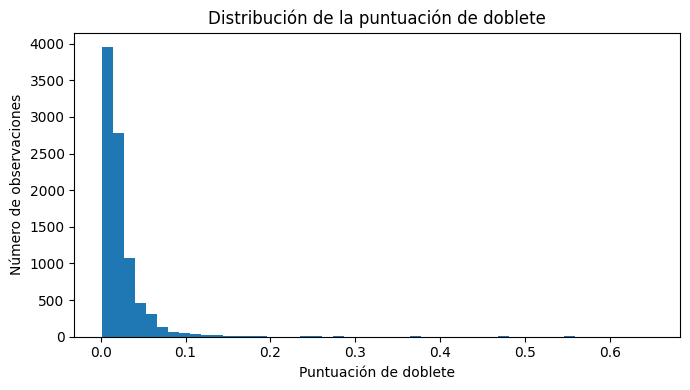

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.hist(adata_qc.obs["doublet_score"], bins=50)

plt.xlabel("Puntuación de doblete")
plt.ylabel("Número de observaciones")
plt.title("Distribución de la puntuación de doblete")

plt.tight_layout()
plt.show()

## **2.3. Normalización de los datos**


### **2.3.1. Motivación de la normalización**

En este trabajo, se aplica una normalización basada en el escalado del número total de conteos por célula, utilizando la función `normalize_total()` de **Scanpy**, seguida de una transformación logarítmica mediante `log1p`. Esta combinación permite:

- hacer comparables las observaciones entre sí,
- reducir la influencia de valores extremos,
- y aproximar la distribución de los datos a una forma más adecuada para técnicas posteriores como la reducción de dimensionalidad o el clustering.



### **2.3.2. Aplicación de la normalización**

La normalización se realiza utilizando la función `normalize_total()` de **Scanpy**, fijando como referencia un total de 10.000 conteos por observación. Posteriormente, se aplica la transformación `log1p`, que reduce la asimetría de la distribución y modera la influencia de valores extremos.

In [ ]:
# Guardar conteos originales
adata_qc.layers["counts"] = adata_qc.X.copy()

# Normalización por total de conteos (CP10k por defecto)
sc.pp.normalize_total(adata_qc, target_sum=1e4)

# Transformación logarítmica
sc.pp.log1p(adata_qc)

print("Normalización y transformación logarítmica completadas")
print(adata_qc)

Normalización y transformación logarítmica completadas
AnnData object with n_obs × n_vars = 8978 × 18387
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'qc_paper_filter', 'doublet_score', 'predicted_doublet'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'


### **2.3.3. Verificación básica de la transformación**

Tras la normalización, se inspecciona de forma preliminar cómo ha cambiado la distribución global de la señal.

En particular, puede compararse la distribución de los conteos totales originales con la suma de los valores transformados tras la normalización logarítmica.

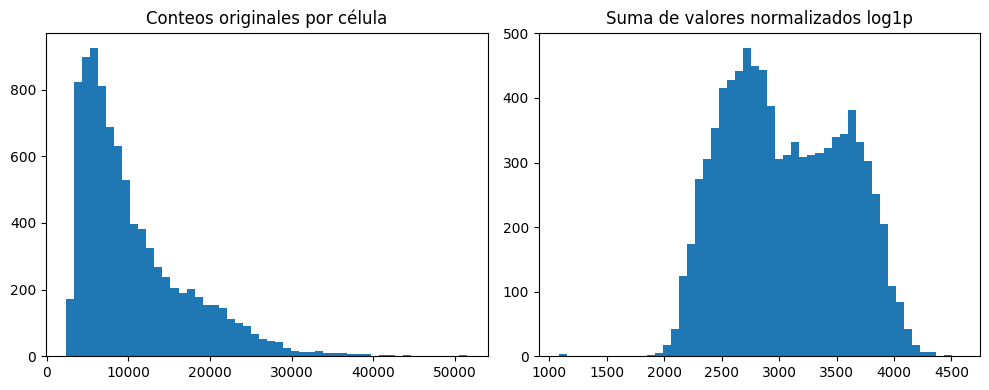

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(adata_qc.layers["counts"].sum(axis=1).A1 if hasattr(adata_qc.layers["counts"], "A1") else adata_qc.layers["counts"].sum(axis=1), bins=50)
axes[0].set_title("Conteos originales por célula")

axes[1].hist(adata_qc.X.sum(axis=1).A1 if hasattr(adata_qc.X, "A1") else adata_qc.X.sum(axis=1), bins=50)
axes[1].set_title("Suma de valores normalizados log1p")

plt.tight_layout()
plt.show()

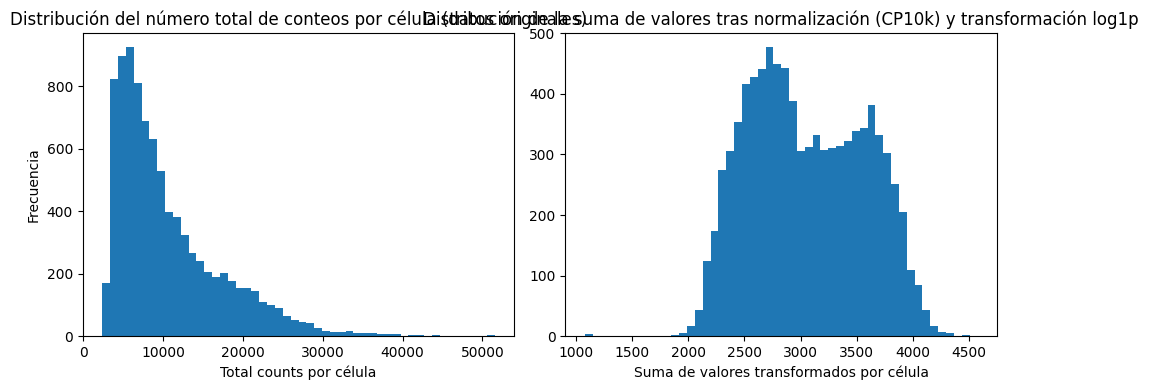

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteos originales
axes[0].hist(
    adata_qc.layers["counts"].sum(axis=1).A1
    if hasattr(adata_qc.layers["counts"], "A1")
    else adata_qc.layers["counts"].sum(axis=1),
    bins=50
)
axes[0].set_title("Distribución del número total de conteos por célula (datos originales)")
axes[0].set_xlabel("Total counts por célula")
axes[0].set_ylabel("Frecuencia")

# Datos normalizados + log1p
axes[1].hist(
    adata_qc.X.sum(axis=1).A1
    if hasattr(adata_qc.X, "A1")
    else adata_qc.X.sum(axis=1),
    bins=50
)
axes[1].set_title("Distribución de la suma de valores tras normalización (CP10k) y transformación log1p")
axes[1].set_xlabel("Suma de valores transformados por célula")

plt.tight_layout()
plt.show()

## **2.4. Selección de características (Feature Selection)**

### **2.4.1. Identificación de genes altamente variables (HVGs)**

Como siguiente paso en el pipeline, se procede a reducir la dimensionalidad del dataset seleccionando únicamente los genes más informativos. Este proceso se lleva a cabo mediante la identificación de **genes altamente variables** (*Highly Variable Genes, HVGs*), siguiendo la metodología implementada en **Scanpy**.

La función `pp.highly_variable_genes()` permite identificar estos genes reproduciendo distintos enfoques ampliamente utilizados en el ámbito del análisis de *single-cell RNA-seq*, como los propuestos en **Seurat**, **Cell Ranger** o **Seurat v3**, en función del parámetro `flavor` seleccionado.

En este caso, se seleccionan los **2.000 genes más variables**, un valor estándar en la literatura que permite capturar la mayor parte de la variabilidad biológica sin introducir un exceso de ruido.




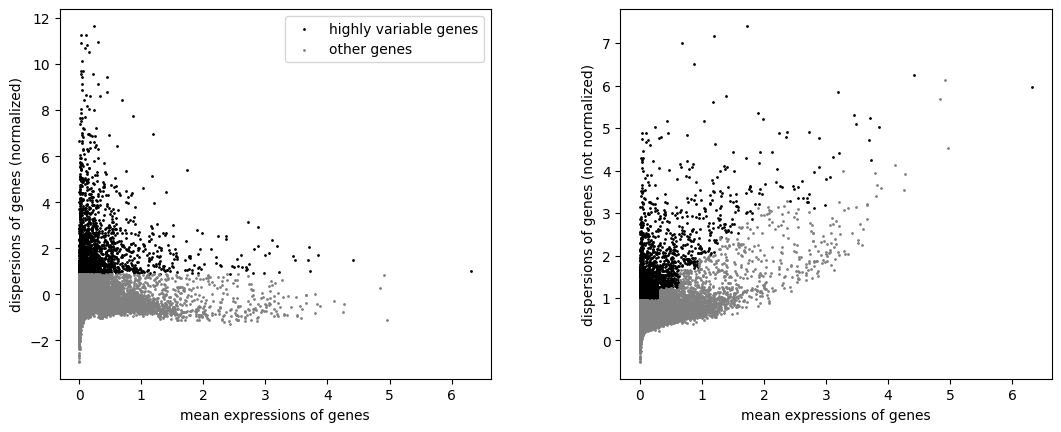

In [ ]:
# Identificación de genes altamente variables
sc.pp.highly_variable_genes(adata_qc, n_top_genes=2000)

# Visualización de los genes seleccionados
sc.pl.highly_variable_genes(adata_qc)

In [ ]:
# Filtrado del dataset para conservar únicamente los HVGs
adata_hvg = adata_qc[:, adata_qc.var["highly_variable"]].copy()

print("Nuevo tamaño tras selección de HVGs:", adata_hvg.shape)

Nuevo tamaño tras selección de HVGs: (8978, 2000)


## **2.5. Reducción de dimensionalidad (Dimensionality Reduction)**

Entre los métodos más utilizados destacan **PCA**, **t-SNE** y **UMAP**, todos ellos implementados en **Scanpy**. En particular, PCA se emplea habitualmente como primer paso para capturar las principales fuentes de variación, mientras que UMAP y t-SNE permiten obtener representaciones no lineales más adecuadas para la visualización de la estructura celular.


### **2.5.1. Análisis de Componentes Principales (PCA)**

El PCA es una técnica lineal que transforma los datos en un nuevo espacio de variables no correlacionadas (componentes principales), ordenadas según la varianza que explican.

En este trabajo, se aplica PCA sobre los genes altamente variables con el objetivo de capturar las principales fuentes de variación del dataset.

In [ ]:
# PCA sobre HVGs
sc.pp.pca(adata_hvg, svd_solver="arpack")

print("PCA completado")

PCA completado


### **2.5.2. Selección del número de componentes principales**

Tras aplicar PCA, es necesario determinar cuántos componentes principales retener. Para ello, se analiza la proporción de varianza explicada por cada componente.

En la práctica, se suelen seleccionar entre 10 y 50 componentes principales para los análisis posteriores.

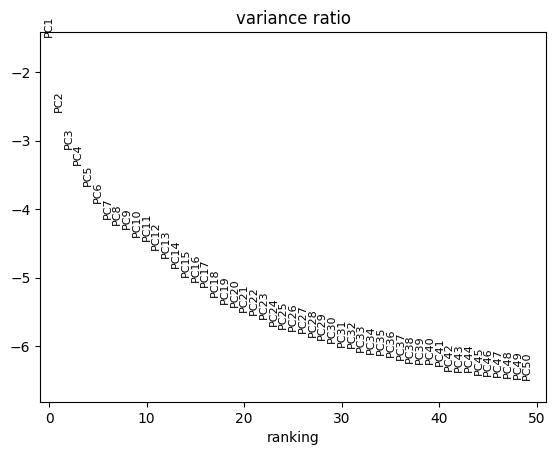

In [ ]:
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50, log=True)

### **2.5.3. Construcción del grafo de vecinos**

A partir de la representación en el espacio PCA, se construye un grafo de vecinos que modela la similitud entre células.

Este grafo es fundamental para métodos posteriores como UMAP o clustering.

In [ ]:
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=40)

### **2.5.4. Proyección no lineal con UMAP**

UMAP es un método no lineal que permite representar los datos en baja dimensión (2D o 3D), preservando la estructura local y global del dataset.

Se utiliza principalmente para la visualización de poblaciones celulares.

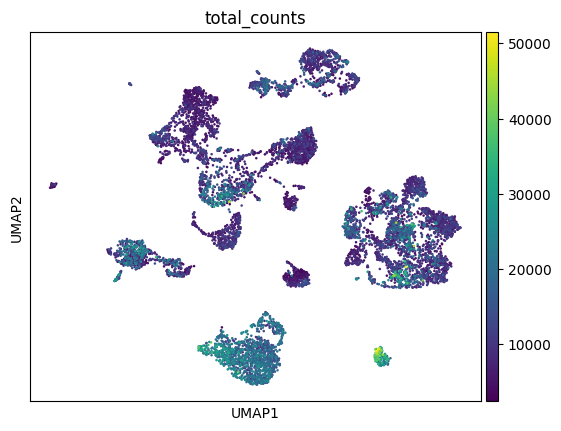

In [ ]:
sc.tl.umap(adata_hvg)

sc.pl.umap(adata_hvg, color="total_counts")

### **2.5.5. Proyección alternativa con t-SNE**

t-SNE es otra técnica no lineal ampliamente utilizada en análisis de *single-cell RNA-seq*.

Aunque suele ofrecer resultados similares a UMAP, es más costosa computacionalmente y puede perder estructura global.

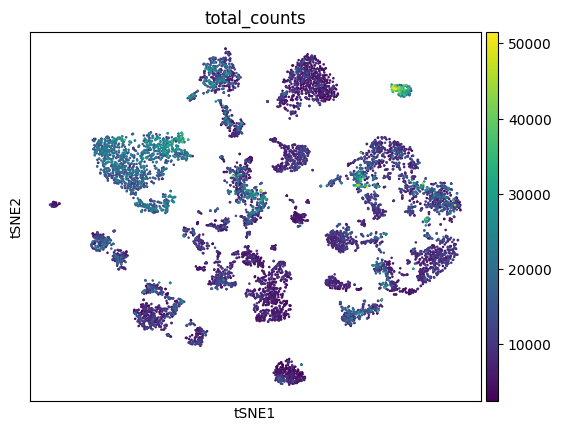

In [ ]:
sc.tl.tsne(adata_hvg, use_rep="X_pca")

sc.pl.tsne(adata_hvg, color="total_counts")

### **2.5.6. Inspección de métricas de calidad en el espacio reducido**

Finalmente, se pueden visualizar métricas de calidad en el espacio UMAP.

```
# Tiene formato de código
```




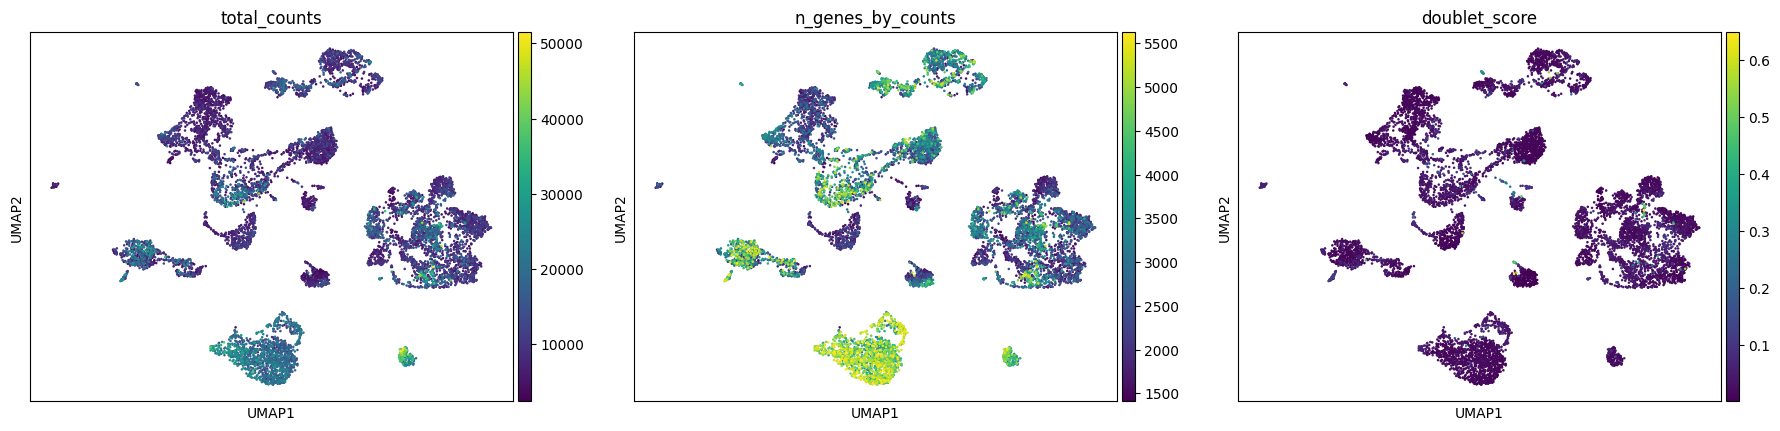

In [ ]:
sc.pl.umap(
    adata_hvg,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "doublet_score"
    ]
)

In [ ]:
print("Tamaño final tras procesamiento:", adata_hvg.shape)

Tamaño final tras procesamiento: (8978, 2000)


# **3. Identificación de la estructura celular (Identifying cellular structure)**

## **3.1. Clustering**

### **3.1.1. Aplicación del algoritmo Leiden**

Una vez construido el grafo de vecinos a partir de la representación en el espacio PCA, se aplica el algoritmo **Leiden** para identificar agrupaciones de células con perfiles de expresión similares.

En este trabajo, el clustering se realiza directamente sobre el objeto previamente preprocesado, utilizando la implementación de Leiden disponible en Scanpy.

In [ ]:
!pip install igraph

In [ ]:
# Aplicación de Leiden (resolución por defecto)
sc.tl.leiden(adata_hvg, flavor="igraph", n_iterations=2)

print("Clustering Leiden completado")
print("Número de clusters:", adata_hvg.obs["leiden"].nunique())

Clustering Leiden completado
Número de clusters: 33


### **3.1.2. Ajuste del parámetro de resolución**

El algoritmo Leiden incorpora un parámetro denominado **resolución**, que controla el nivel de granularidad del clustering.

- Valores bajos de resolución generan un número reducido de clusters (agrupaciones más generales).
- Valores altos producen un mayor número de clusters, permitiendo identificar subestructuras más finas dentro del dataset.

Dado que no existe un valor óptimo universal, es habitual explorar distintos valores de resolución para analizar cómo varía la estructura del clustering.

In [ ]:
# Diferentes resoluciones de Leiden
sc.tl.leiden(adata_hvg, resolution=0.25, key_added="leiden_res_0_25", flavor="igraph", n_iterations=2)
sc.tl.leiden(adata_hvg, resolution=0.5, key_added="leiden_res_0_5", flavor="igraph", n_iterations=2)
sc.tl.leiden(adata_hvg, resolution=1.0, key_added="leiden_res_1", flavor="igraph", n_iterations=2)

### **3.1.3. Visualización del clustering**

Para evaluar el impacto del parámetro de resolución, se visualizan los resultados del clustering sobre la proyección UMAP.

Esto permite analizar cómo varía el número y la separación de clusters en función de la resolución seleccionada.

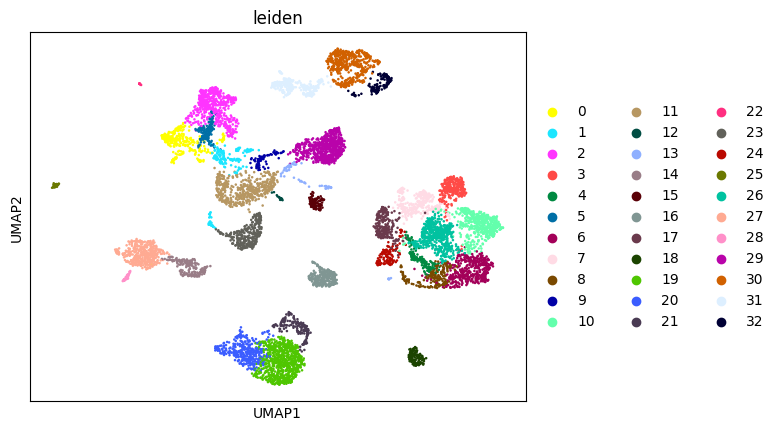

In [ ]:
sc.pl.umap(adata_hvg, color=["leiden"])

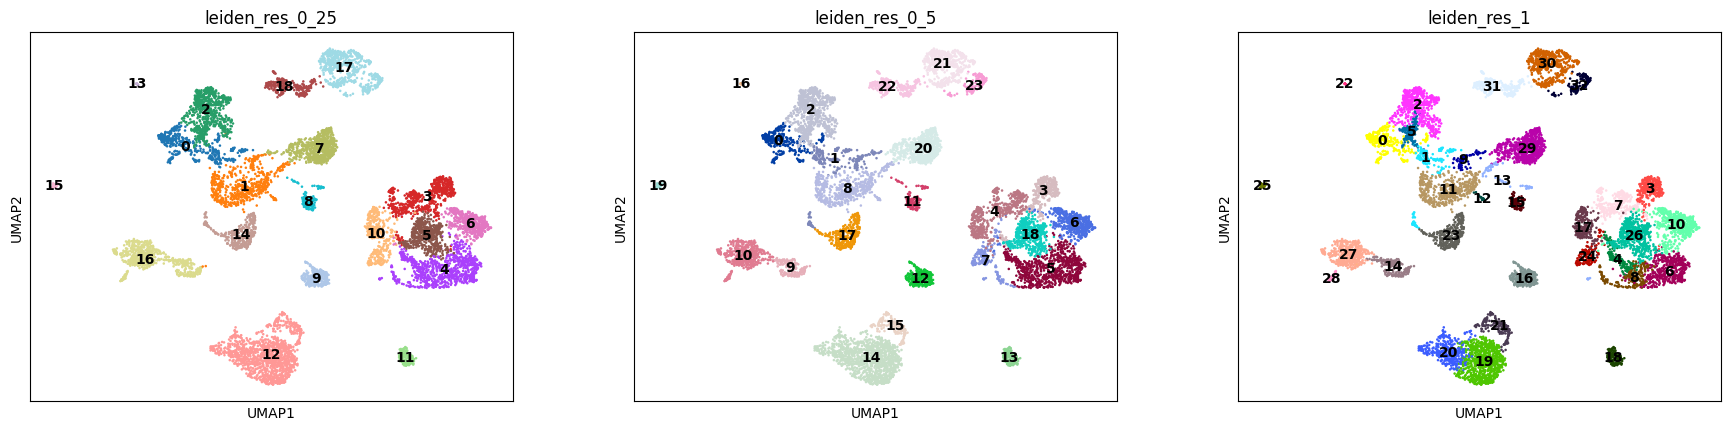

In [ ]:
sc.pl.umap(
    adata_hvg,
    color=["leiden_res_0_25", "leiden_res_0_5", "leiden_res_1"],
    legend_loc="on data"
)

### **3.1.4. Interpretación de los resultados**

El análisis de diferentes resoluciones permite observar cómo el clustering se vuelve más o menos granular:

- A resoluciones bajas, se obtienen menos clusters, más amplios y generales.
- A resoluciones altas, se identifican más clusters, capturando posibles subpoblaciones celulares.

Este comportamiento puede interpretarse como un proceso de “zoom” sobre la estructura del dataset, donde se pasa de una visión global a una más detallada.

Cabe destacar que la visualización mediante UMAP es una proyección en dos dimensiones, por lo que las distancias entre clusters deben interpretarse con cautela.

En el contexto del glioblastoma, este análisis resulta especialmente relevante debido a la alta heterogeneidad celular, permitiendo explorar tanto grandes poblaciones celulares como posibles subtipos más específicos.

## **3.2. Identificación de genes característicos por cluster**

In [ ]:
# Identificación de genes característicos por cluster (ranking)
sc.tl.rank_genes_groups(
    adata_hvg,
    groupby="leiden",   # clustering principal
    method="wilcoxon"
)

print("Ranking de genes por cluster completado")

Ranking de genes por cluster completado


/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:429: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:431: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/usr/local/lib/python3.11/dist-packages/scanpy/tools/_rank_genes_groups.py:434: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

In [ ]:
import pandas as pd

# Extraer resultados
result = adata_hvg.uns["rank_genes_groups"]
clusters = result["names"].dtype.names

top_n = 10  # nº de genes por cluster

# Construir tabla
markers_df = pd.DataFrame({
    f"Cluster {cluster}": result["names"][cluster][:top_n]
    for cluster in clusters
})

markers_df

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,...,Cluster 23,Cluster 24,Cluster 25,Cluster 26,Cluster 27,Cluster 28,Cluster 29,Cluster 30,Cluster 31,Cluster 32
0,ENSG00000144485,ENSG00000123416,ENSG00000104435,ENSG00000159189,ENSG00000159189,ENSG00000118971,ENSG00000147872,ENSG00000095970,ENSG00000196154,ENSG00000132692,...,ENSG00000133048,ENSG00000244734,ENSG00000170290,ENSG00000155659,ENSG00000167614,ENSG00000164611,ENSG00000053438,ENSG00000135446,ENSG00000257698,ENSG00000155980
1,ENSG00000090932,ENSG00000164104,ENSG00000015592,ENSG00000121933,ENSG00000173369,ENSG00000144485,ENSG00000130592,ENSG00000130208,ENSG00000090382,ENSG00000006468,...,ENSG00000064886,ENSG00000198502,ENSG00000106483,ENSG00000169508,ENSG00000087250,ENSG00000108106,ENSG00000147862,ENSG00000135506,ENSG00000152583,ENSG00000175203
2,ENSG00000256618,ENSG00000175063,ENSG00000256618,ENSG00000173369,ENSG00000204472,ENSG00000106415,ENSG00000169429,ENSG00000125730,ENSG00000197747,ENSG00000175130,...,ENSG00000008394,ENSG00000177575,ENSG00000162998,ENSG00000011422,ENSG00000170075,ENSG00000198901,ENSG00000137285,ENSG00000111581,ENSG00000135916,ENSG00000178498
3,ENSG00000145284,ENSG00000131747,ENSG00000214548,ENSG00000204472,ENSG00000173372,ENSG00000104435,ENSG00000135046,ENSG00000121933,ENSG00000025708,ENSG00000145284,...,ENSG00000176907,ENSG00000121966,ENSG00000176046,ENSG00000203747,ENSG00000179604,ENSG00000143228,ENSG00000167552,ENSG00000175203,ENSG00000113140,ENSG00000135506
4,ENSG00000132692,ENSG00000077152,ENSG00000117632,ENSG00000006075,ENSG00000132965,ENSG00000053438,ENSG00000197930,ENSG00000130203,ENSG00000120708,ENSG00000187416,...,ENSG00000102265,ENSG00000167995,ENSG00000136235,ENSG00000170458,ENSG00000101439,ENSG00000137804,ENSG00000168824,ENSG00000178498,ENSG00000240583,ENSG00000135454
5,ENSG00000189058,ENSG00000164611,ENSG00000167552,ENSG00000122862,ENSG00000170458,ENSG00000256618,ENSG00000136235,ENSG00000171659,ENSG00000132965,ENSG00000160307,...,ENSG00000131981,ENSG00000179344,ENSG00000120885,ENSG00000150337,ENSG00000101955,ENSG00000117724,ENSG00000117632,ENSG00000006468,ENSG00000105854,ENSG00000135446
6,ENSG00000184221,ENSG00000089685,ENSG00000053438,ENSG00000130208,ENSG00000122862,ENSG00000072182,ENSG00000100292,ENSG00000118785,ENSG00000169508,ENSG00000205927,...,ENSG00000149131,ENSG00000223865,ENSG00000250722,ENSG00000173391,ENSG00000092758,ENSG00000100526,ENSG00000134138,ENSG00000135452,ENSG00000131095,ENSG00000257698
7,ENSG00000166091,ENSG00000168078,ENSG00000175130,ENSG00000173372,ENSG00000155659,ENSG00000015592,ENSG00000197747,ENSG00000203747,ENSG00000143119,ENSG00000053438,...,ENSG00000125148,ENSG00000204287,ENSG00000107317,ENSG00000177575,ENSG00000125148,ENSG00000088325,ENSG00000175130,ENSG00000175782,ENSG00000168309,ENSG00000175782
8,ENSG00000116147,ENSG00000113810,ENSG00000124766,ENSG00000171051,ENSG00000019582,ENSG00000124766,ENSG00000130066,ENSG00000175899,ENSG00000135046,ENSG00000167552,...,ENSG00000106211,ENSG00000196126,ENSG00000113140,ENSG00000173369,ENSG00000221932,ENSG00000077152,ENSG00000124766,ENSG00000123297,ENSG00000152661,ENSG00000255737
9,ENSG00000175130,ENSG00000164109,ENSG00000105880,ENSG00000132965,ENSG00000110077,ENSG00000165795,ENSG00000090382,ENSG00000204472,ENSG00000130592,ENSG00000123416,...,ENSG00000115380,ENSG00000234745,ENSG00000109846,ENSG00000204472,ENSG00000018625,ENSG00000123416,ENSG00000162374,ENSG00000147889,ENSG00000178498,ENSG00000214548


### **3.2.1. Visualización de genes marcador**

Para facilitar la interpretación, se visualizan los genes más representativos de cada cluster mediante gráficos que muestran su nivel de expresión relativa.

Estas visualizaciones permiten identificar patrones diferenciales de expresión entre clusters.

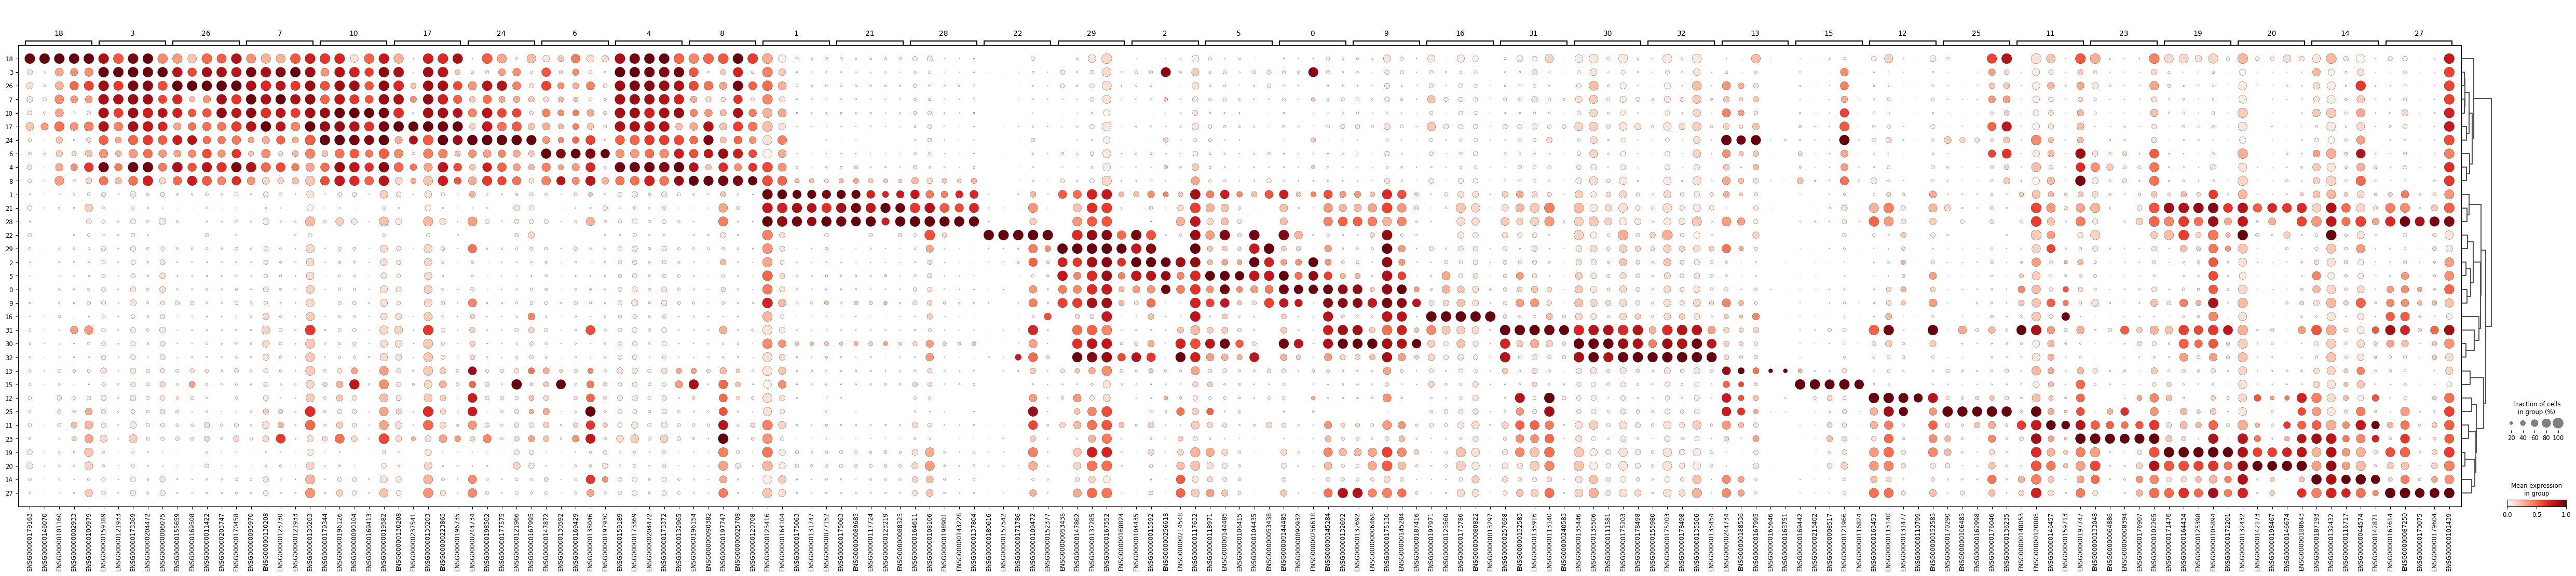

In [ ]:
# Visualización de los genes más representativos
sc.pl.rank_genes_groups_dotplot(
    adata_hvg,
    groupby="leiden",
    n_genes=5,
    standard_scale="var"
)

# **4. Técnicas de Machine Learning y Deep Learning: entrenamiento de modelos**

ENTRENAMIENTO DE MODELOS - 10x
* **Modelos:** SVM, Random Forest, ACTINN, CellTypist, PySingleCellNet
* **Ground truth:** pseudoetiquetas



### **Datos**

* Etiqueta: leiden
* Split train / test


In [ ]:
print(adata_hvg.obs[["leiden"]].head())

      leiden
102_1      0
102_2      0
102_5      0
102_7      2
102_8      2


In [ ]:
import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    adjusted_rand_score, normalized_mutual_info_score,
    classification_report
)

# Pseudo-etiquetas: clusters Leiden
label_col = "leiden"

X = adata_hvg.X
y_labels = adata_hvg.obs[label_col].astype(str).values

le = LabelEncoder()
y = le.fit_transform(y_labels)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#tabla resultados
resultados_modelos = []
predicciones_modelos = {}

def evaluar_modelo(nombre, y_true, y_pred):
    resultados_modelos.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "ari": adjusted_rand_score(y_true, y_pred),
        "nmi": normalized_mutual_info_score(y_true, y_pred)
    })

    predicciones_modelos[nombre] = (y_true, y_pred)

    print(f"\nModelo: {nombre}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1-macro: {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")

## **4.1. Entrenamiento modelos**

#### **SVM**

In [ ]:
from sklearn.svm import LinearSVC

svm_model = make_pipeline(
    MaxAbsScaler(),
    LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=5000
    )
)

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

evaluar_modelo("SVM", y_test, y_pred_svm)


Modelo: SVM
Accuracy: 0.9627
F1-macro: 0.9564


#### **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

evaluar_modelo("Random Forest", y_test, y_pred_rf)


Modelo: Random Forest
Accuracy: 0.9543
F1-macro: 0.9430


#### **ACTINN**


In [ ]:
!git clone https://github.com/mafeiyang/ACTINN.git

# Comprobar ayuda
!python ACTINN/actinn_predict.py -h

Cloning into 'ACTINN'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 159 (delta 0), reused 1 (delta 0), pack-reused 155 (from 1)
Receiving objects: 100% (159/159), 16.78 MiB | 16.88 MiB/s, done.
Resolving deltas: 100% (58/58), done.
2026-05-13 09:50:03.783952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778665803.846663   11588 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778665803.866163   11588 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
usage: actinn_predict.py [-h] [-trs TRAIN_SET] [-trl TRAIN_LABEL]
                         [-ts TEST_SE

In [ ]:

import os
import numpy as np
import pandas as pd
from scipy import sparse

# 1. Convertir matrices a array
X_train_a = X_train.toarray() if sparse.issparse(X_train) else np.asarray(X_train)
X_test_a  = X_test.toarray() if sparse.issparse(X_test) else np.asarray(X_test)

# 2. Crear nombres de genes y células
genes = adata_hvg.var_names.astype(str).values

cells_train = [f"train_{i}" for i in range(X_train_a.shape[0])]
cells_test  = [f"test_{i}" for i in range(X_test_a.shape[0])]

# 3. ACTINN espera genes x células
train_df = pd.DataFrame(X_train_a.T, index=genes, columns=cells_train)
test_df  = pd.DataFrame(X_test_a.T,  index=genes, columns=cells_test)

# 4. Guardar matrices en HDF5
train_df.to_hdf("actinn_train_set.h5", key="dge", mode="w")
test_df.to_hdf("actinn_test_set.h5", key="dge", mode="w")

# 5. Guardar etiquetas de entrenamiento
train_labels = pd.DataFrame({
    "cell": cells_train,
    "label": y_train.astype(str)
})

train_labels.to_csv(
    "actinn_train_label.txt.gz",
    sep="\t",
    index=False,
    header=False,
    compression="gzip"
)

# 6. Guardar etiquetas reales de test para evaluar después
test_labels = pd.DataFrame({
    "cell": cells_test,
    "true_label": y_test
})

test_labels.to_csv("actinn_test_true_labels.csv", index=False)

In [ ]:
# PARCHE TENSORFLOW 2.x


path = "ACTINN/actinn_predict.py"

with open(path, "r") as f:
    code = f.read()

code = code.replace(
    "import tensorflow as tf",
    "import tensorflow.compat.v1 as tf\n"
    "tf.disable_v2_behavior()"
)

code = code.replace(
    "tf.contrib.layers.xavier_initializer(seed = 3)",
    "tf.keras.initializers.GlorotUniform(seed=3)"
)

code = code.replace(
    "tf.contrib.layers.xavier_initializer(seed=3)",
    "tf.keras.initializers.GlorotUniform(seed=3)"
)

code = code.replace(
    "p = tf.nn.softmax(z4, axis=0)",
    "p = tf.exp(z4) / tf.reduce_sum(tf.exp(z4), axis=0, keepdims=True)"
)

code = code.replace(
    "p = tf.nn.softmax(z4, dim=0)",
    "p = tf.exp(z4) / tf.reduce_sum(tf.exp(z4), axis=0, keepdims=True)"
)

with open(path, "w") as f:
    f.write(code)

print("ACTINN preparado")

ACTINN preparado


In [ ]:
# Borrar salida anterior
if os.path.exists("predicted_label.txt"):
    os.remove("predicted_label.txt")

!python ACTINN/actinn_predict.py \
    -trs actinn_train_set.h5 \
    -trl actinn_train_label.txt.gz \
    -ts actinn_test_set.h5 \
    -lr 0.0001 \
    -ne 50 \
    -ms 128 \
    -pc True \
    -op False

2026-05-13 09:56:36.159371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778666196.200196   13174 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778666196.213144   13174 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Instructions for updating:
non-resource variables are not supported in the long term
Cell Types in training set: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32}
# Trainng cells: 7182
2026-05-13 09:56:45.259559: E external/local_xla/xla/stre

In [ ]:
#COMPROBAR SALIDA

!ls

pred = pd.read_csv(
    "predicted_label.txt",
    sep="\t",
    header=None,
    names=["cell", "predicted_label"]
)

pred.head()

ACTINN			     drive
actinn_test_set.h5	     predicted_label.txt
actinn_test_true_labels.csv  predicted_probabilities.txt
actinn_train_label.txt.gz    sample_data
actinn_train_set.h5


,cell,predicted_label
0,cellname,celltype
1,test_0,11
2,test_1,31
3,test_2,3
4,test_3,3


In [ ]:
# EVALUACIÓN


pred_actinn = pd.read_csv("predicted_label.txt", sep="\t", header=None)
pred_actinn.columns = ["cell", "predicted_label"]

true_actinn = pd.read_csv("actinn_test_true_labels.csv")

eval_actinn = true_actinn.merge(pred_actinn, on="cell", how="inner")

y_true_actinn = eval_actinn["true_label"].astype(int).values
y_pred_actinn = eval_actinn["predicted_label"].astype(int).values

evaluar_modelo("ACTINN", y_true_actinn, y_pred_actinn)


Modelo: ACTINN
Accuracy: 0.9499
F1-macro: 0.9375


#### **Celltypist**


In [ ]:
!pip install celltypist -q

In [ ]:
import celltypist
import numpy as np
import scanpy as sc
from sklearn.model_selection import train_test_split

# ============================================================
# 1. SPLIT
# ============================================================

indices = np.arange(adata_hvg.n_obs)

idx_train, idx_test = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=adata_hvg.obs["leiden"].values
)

# ============================================================
# 2. PREPARAR DATOS PARA CELLTYPIST
# ============================================================

adata_celltypist = adata_hvg.copy()

# Usar clusters Leiden como pseudo-etiquetas
adata_celltypist.obs["pseudo_label"] = adata_celltypist.obs["leiden"].astype(str)

# CellTypist espera log1p normalizado a 10.000 cuentas por célula
# Si tienes counts originales en una capa, se usan; si no, se renormaliza X.
if "counts" in adata_celltypist.layers:
    adata_celltypist.X = adata_celltypist.layers["counts"].copy()
elif "original" in adata_celltypist.layers:
    adata_celltypist.X = adata_celltypist.layers["original"].copy()

sc.pp.normalize_total(adata_celltypist, target_sum=1e4)
sc.pp.log1p(adata_celltypist)

# Split
adata_train = adata_celltypist[idx_train].copy()
adata_test = adata_celltypist[idx_test].copy()

adata_train.obs["pseudo_label"] = adata_train.obs["pseudo_label"].astype("category")

# Matriz densa
if hasattr(adata_train.X, "toarray"):
    adata_train.X = adata_train.X.toarray()
if hasattr(adata_test.X, "toarray"):
    adata_test.X = adata_test.X.toarray()

# ============================================================
# 3. ENTRENAR MODELO
# ============================================================

celltypist_model = celltypist.train(
    adata_train,
    labels="pseudo_label",
    n_jobs=4,
    feature_selection=True,
    check_expression=True
)

# ============================================================
# 4. PREDICCIÓN
# ============================================================

pred_celltypist = celltypist.annotate(
    adata_test,
    model=celltypist_model,
    majority_voting=False
)

y_pred_celltypist_labels = (
    pred_celltypist.predicted_labels["predicted_labels"]
    .astype(str)
    .values
)

# ============================================================
# 5. CONVERTIR A NUMÉRICO
# ============================================================

label_map = {str(cls): i for i, cls in enumerate(le.classes_)}

y_pred_celltypist = np.array([
    label_map[l] for l in y_pred_celltypist_labels
])

# Verdadero test
y_test_celltypist = np.array([
    label_map[str(l)] for l in adata_test.obs["pseudo_label"].values
])

# ============================================================
# 6. EVALUACIÓN
# ============================================================

evaluar_modelo("CellTypist", y_test_celltypist, y_pred_celltypist)


Modelo: CellTypist
Accuracy: 0.9538
F1-macro: 0.9420


 #### **PySingleCellNet**

In [ ]:
# PySingleCellNet

!pip install git+https://github.com/CahanLab/PySingleCellNet.git

  Cloning https://github.com/CahanLab/PySingleCellNet.git to /tmp/pip-req-build-kj87c704
  Running command git clone --filter=blob:none --quiet https://github.com/CahanLab/PySingleCellNet.git /tmp/pip-req-build-kj87c704
  Resolved https://github.com/CahanLab/PySingleCellNet.git to commit 09f8f10cd2508068e4e690abd9966930622f9d6c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib
import matplotlib.pyplot as plt

# parche matplotlib
plt.Colormap = matplotlib.colors.Colormap

import pySingleCellNet as cn

from sklearn.model_selection import train_test_split

In [ ]:
# ============================================================
# PREPARAR DATOS
# ============================================================

adata_scn = adata_hvg.copy()

adata_scn.obs["leiden_label"] = (
    adata_scn.obs["leiden"]
    .astype(str)
    .astype("category")
)

idx = np.arange(adata_scn.n_obs)

idx_train, idx_test = train_test_split(
    idx,
    test_size=0.2,
    random_state=42,
    stratify=adata_scn.obs["leiden_label"]
)

adTrain = adata_scn[idx_train].copy()
adTest  = adata_scn[idx_test].copy()

In [ ]:
# ============================================================
# ENTRENAR SINGLECELLNET
# ============================================================

clf = cn.tl.train_classifier(
    adTrain,
    "leiden_label",
    nRand=100,
    nTopGenes=30,
    nTopGenePairs=40,
    n_comps=30
)

print("Clasificador entrenado")

Training classifier |████████████████████████████████████████| 5/5 [100%] in 1:37.3 (0.05/s) 
Clasificador entrenado


In [ ]:
# ============================================================
# PREDECIR
# ============================================================

cn.tl.classify_anndata(adTest, clf)

adTest.obs[[
    "leiden_label",
    "SCN_class_argmax"
]].head()

,leiden_label,SCN_class_argmax
143_7d_1642,19,19
124_2_314,8,8
124_2_289,11,11
124_1_608,11,11
115_1_309,27,27


In [ ]:
# ============================================================
# EVALUAR
# ============================================================

y_true_scn = (
    adTest.obs["leiden_label"]
    .astype(str)
    .values
)

y_pred_scn = (
    adTest.obs["SCN_class_argmax"]
    .astype(str)
    .values
)

evaluar_modelo(
    "SingleCellNet",
    y_true_scn,
    y_pred_scn
)


Modelo: SingleCellNet
Accuracy: 0.9337
F1-macro: 0.8836


## **4.2. Tabla resumen de resultados**
Con el fin de facilitar la comparación entre modelos, los resultados obtenidos se sintetizan en una tabla resumen.

In [ ]:
df_resultados = pd.DataFrame(resultados_modelos)
df_resultados = df_resultados.sort_values("f1_macro", ascending=False)

df_resultados

,modelo,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,ari,nmi
0,SVM,0.962695,0.957002,0.959590,0.957002,0.956364,0.927023,0.949956
3,Random Forest,0.954343,0.926917,0.969045,0.926917,0.943001,0.916426,0.941500
2,CellTypist,0.953786,0.931679,0.961203,0.931679,0.942008,0.912659,0.940667
1,ACTINN,0.949889,0.930328,0.952843,0.930328,0.937525,0.911178,0.933874
4,SingleCellNet,0.933742,0.859841,0.928218,0.859841,0.883615,0.882003,0.920163


In [ ]:
df_resultados = pd.DataFrame(resultados_modelos)
df_resultados = df_resultados.sort_values("f1_macro", ascending=False)
df_resultados

,modelo,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,ari,nmi
0,SVM,0.962695,0.957002,0.959590,0.957002,0.956364,0.927023,0.949956
3,Random Forest,0.954343,0.926917,0.969045,0.926917,0.943001,0.916426,0.941500
2,CellTypist,0.953786,0.931679,0.961203,0.931679,0.942008,0.912659,0.940667
1,ACTINN,0.949889,0.930328,0.952843,0.930328,0.937525,0.911178,0.933874
4,SingleCellNet,0.933742,0.859841,0.928218,0.859841,0.883615,0.882003,0.920163


## **4.3. Visualización de resultados**

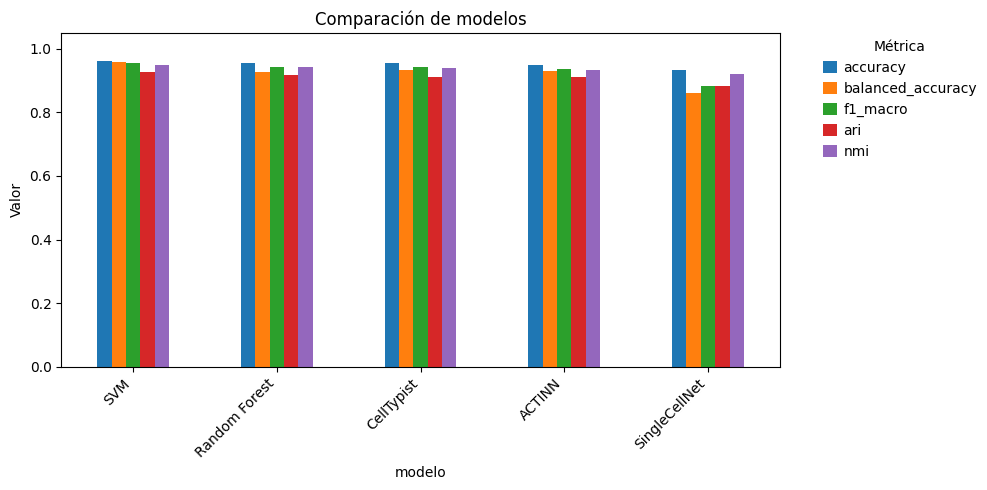

In [ ]:
import matplotlib.pyplot as plt

metricas = ["accuracy", "balanced_accuracy", "f1_macro", "ari", "nmi"]

df_plot = df_resultados.set_index("modelo")[metricas]

ax = df_plot.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.title("Comparación de modelos")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

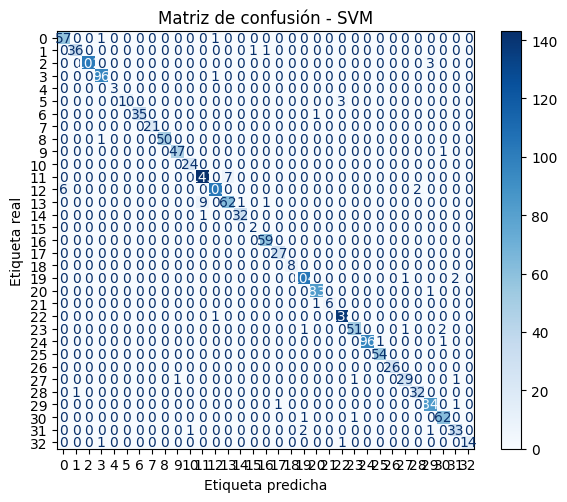

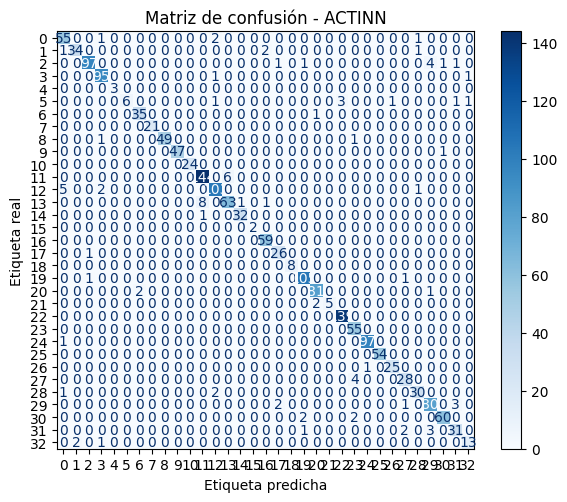

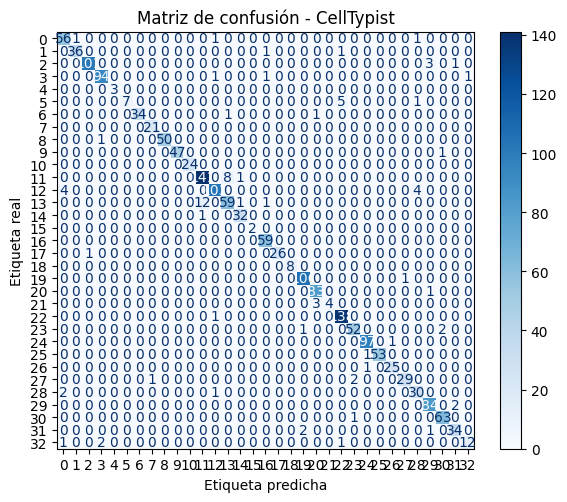

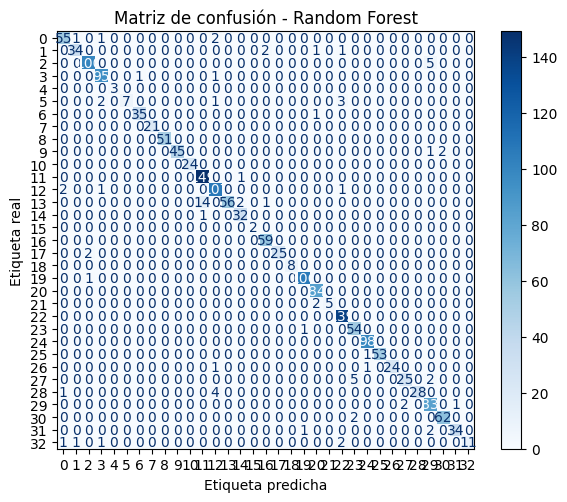

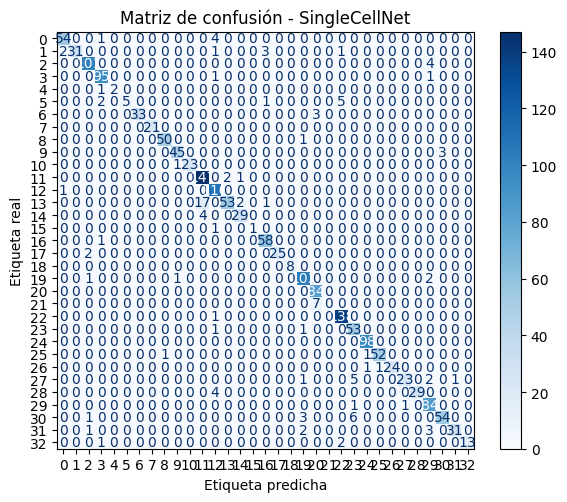

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for nombre, (y_true, y_pred) in predicciones_modelos.items():
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=True)

    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Etiqueta predicha")
    plt.ylabel("Etiqueta real")
    plt.tight_layout()
    plt.show()

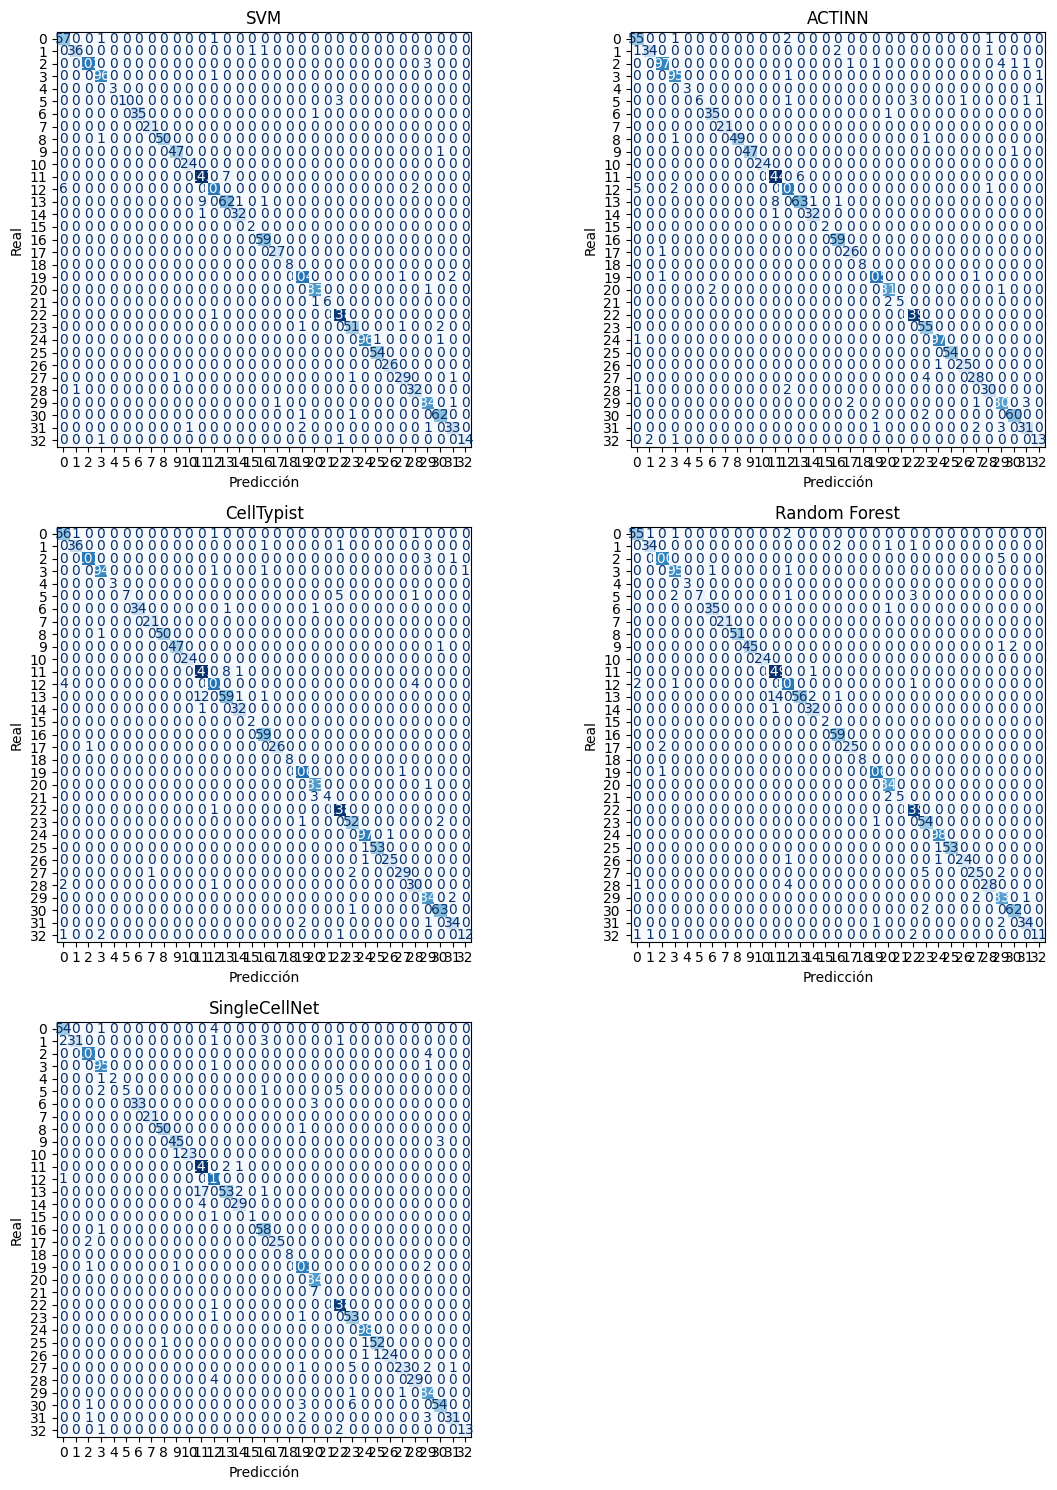

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import math

# Número de modelos
n_modelos = len(predicciones_modelos)

# Grid automático
ncols = 2
nrows = math.ceil(n_modelos / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(12, 5 * nrows)
)

axes = axes.flatten()

for ax, (nombre, (y_true, y_pred)) in zip(axes, predicciones_modelos.items()):

    # SIN normalizar
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

# Eliminar ejes vacíos
for i in range(len(predicciones_modelos), len(axes)):
    fig.delaxes(axes[i])



plt.tight_layout()
plt.show()

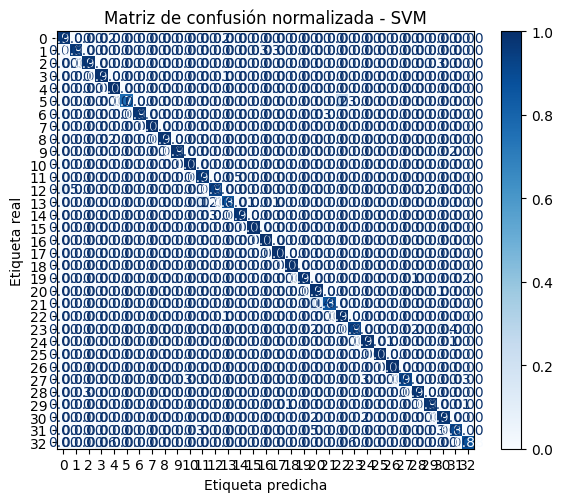

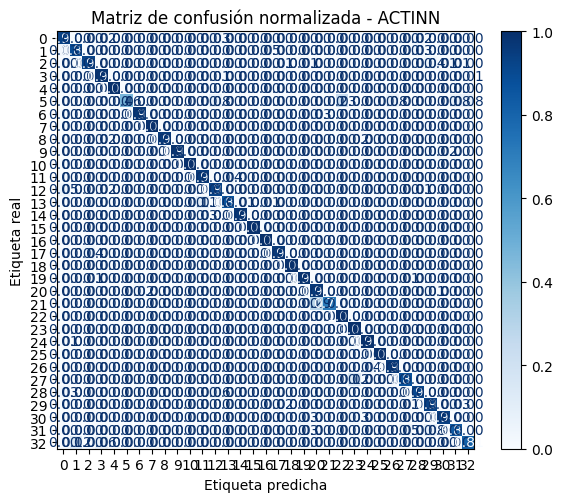

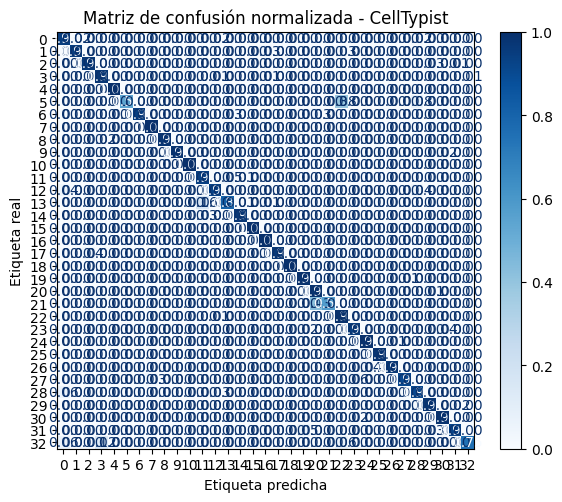

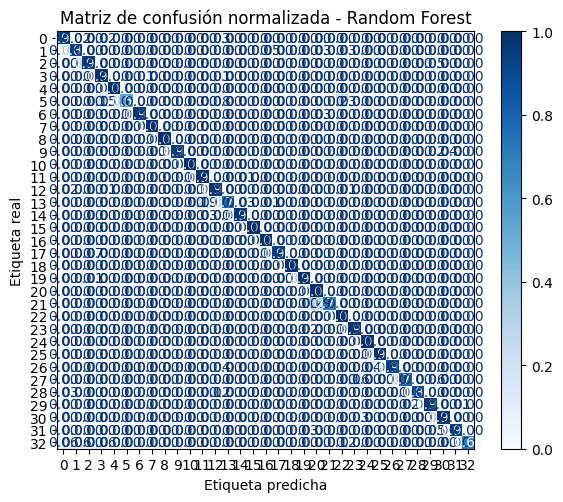

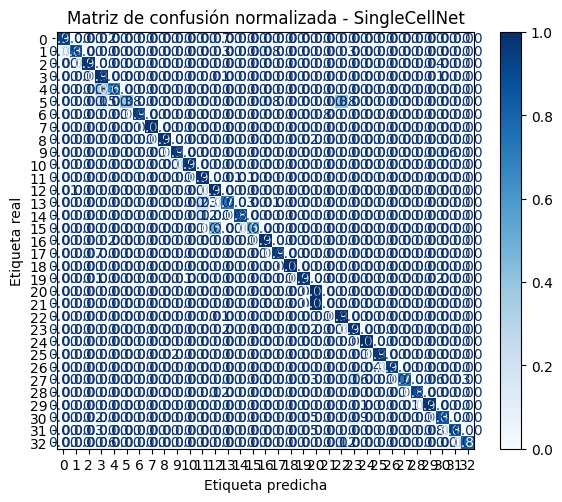

In [ ]:
for nombre, (y_true, y_pred) in predicciones_modelos.items():
    cm = confusion_matrix(y_true, y_pred, normalize="true")

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format=".2f")

    plt.title(f"Matriz de confusión normalizada - {nombre}")
    plt.xlabel("Etiqueta predicha")
    plt.ylabel("Etiqueta real")
    plt.tight_layout()
    plt.show()